In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv("financial_credit_risk.csv")
df.head()

,Age,Income,LoanAmount,CreditScore,EmploymentYears,DebtRatio,PreviousDefaults,LoanApproved
0,25,32000,8000,620,2,0.35,1,0
1,45,85000,12000,720,10,0.20,0,1
2,34,54000,15000,680,6,0.30,0,1
3,29,40000,10000,610,3,0.45,1,0
4,50,90000,20000,750,15,0.18,0,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               20 non-null     int64  
 1   Income            20 non-null     int64  
 2   LoanAmount        20 non-null     int64  
 3   CreditScore       20 non-null     int64  
 4   EmploymentYears   20 non-null     int64  
 5   DebtRatio         20 non-null     float64
 6   PreviousDefaults  20 non-null     int64  
 7   LoanApproved      20 non-null     int64  
dtypes: float64(1), int64(7)
memory usage: 1.4 KB


,Age,Income,LoanAmount,CreditScore,EmploymentYears,DebtRatio,PreviousDefaults,LoanApproved
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,37.80000,61050.000000,14025.000000,676.250000,7.500000,0.312500,0.300000,0.700000
std,9.45126,21924.451623,4458.802648,59.799556,5.365582,0.119819,0.470162,0.470162
min,23.00000,28000.000000,7000.000000,580.000000,1.000000,0.150000,0.000000,0.000000
25%,29.75000,41500.000000,10375.000000,627.500000,3.000000,0.207500,0.000000,0.000000
50%,37.50000,59500.000000,13750.000000,675.000000,6.000000,0.295000,0.000000,1.000000
75%,45.25000,82750.000000,17250.000000,722.500000,10.250000,0.405000,1.000000,1.000000
max,55.00000,95000.000000,22000.000000,780.000000,20.000000,0.550000,1.000000,1.000000


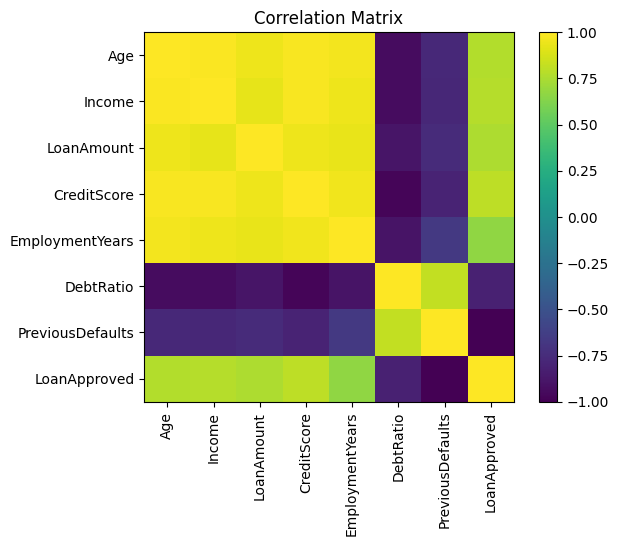

In [4]:
plt.figure()
plt.imshow(df.corr(), interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.title("Correlation Matrix")
plt.show()

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

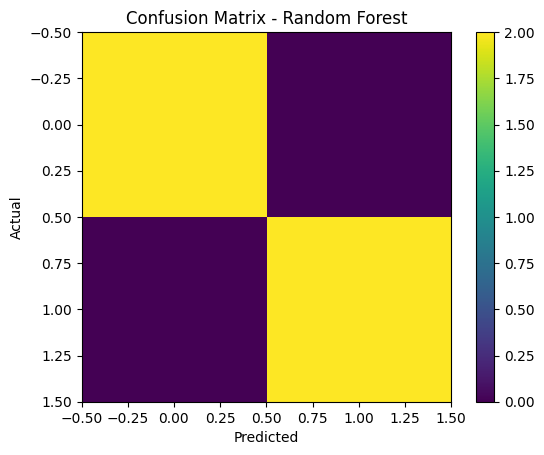

In [12]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

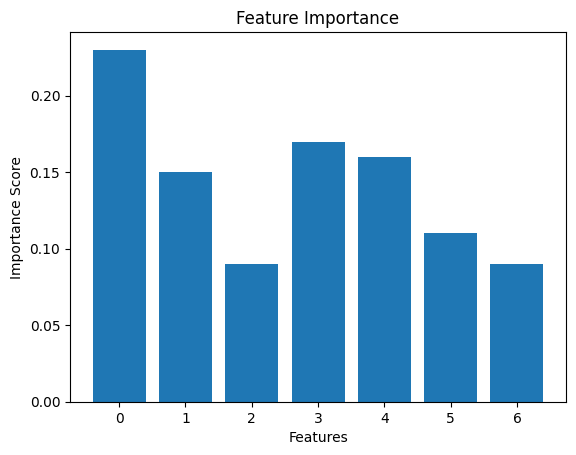

In [13]:
importance = rf.feature_importances_

plt.figure()
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

In [20]:
df.head(5)

,Age,Income,LoanAmount,CreditScore,EmploymentYears,DebtRatio,PreviousDefaults,LoanApproved
0,25,32000,8000,620,2,0.35,1,0
1,45,85000,12000,720,10,0.20,0,1
2,34,54000,15000,680,6,0.30,0,1
3,29,40000,10000,610,3,0.45,1,0
4,50,90000,20000,750,15,0.18,0,1


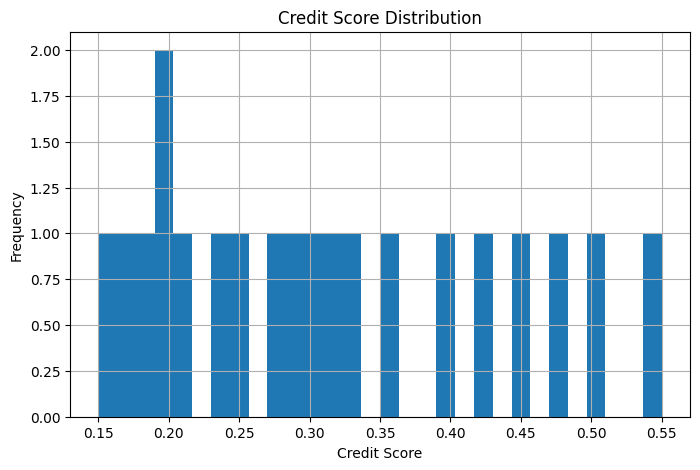

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['DebtRatio'].hist(bins=30)
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

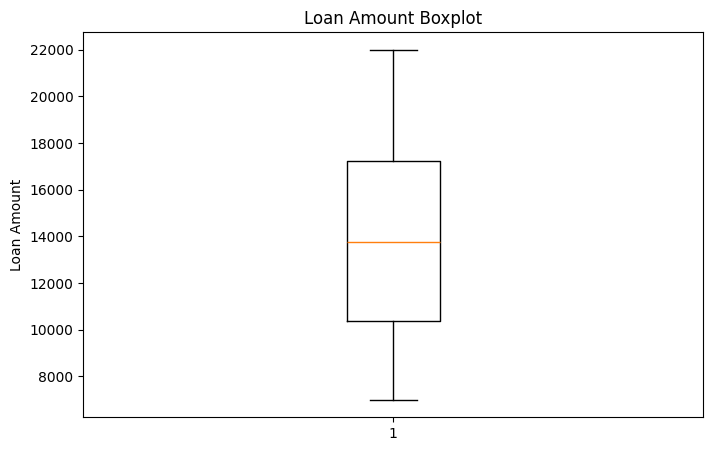

In [23]:
plt.figure(figsize=(8,5))
plt.boxplot(df['LoanAmount'])
plt.title('Loan Amount Boxplot')
plt.ylabel('Loan Amount')
plt.show()

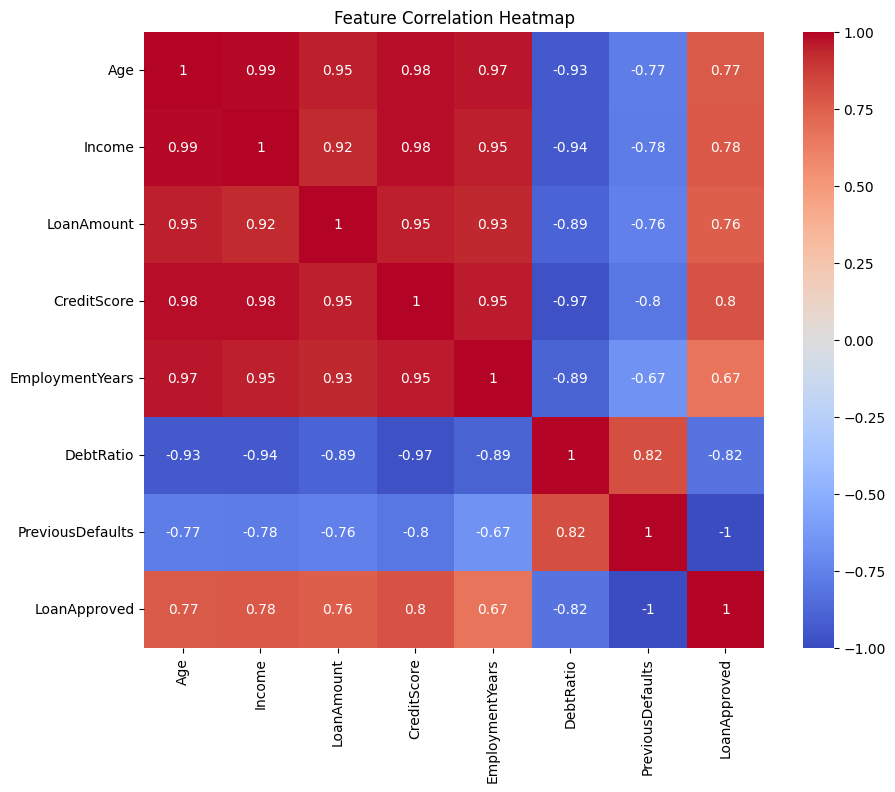

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

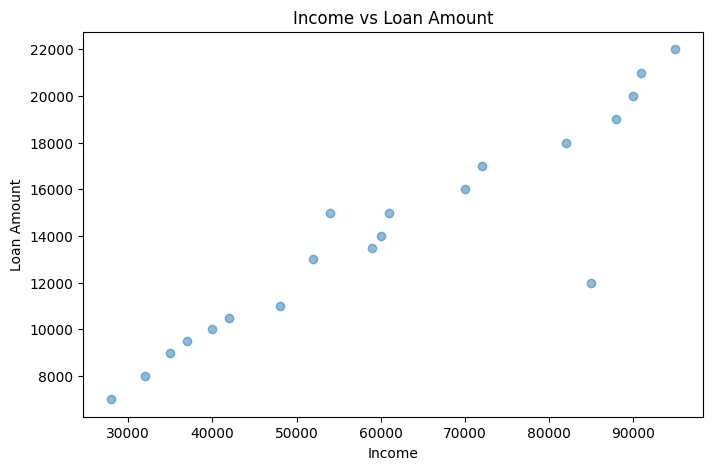

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(df['Income'], df['LoanAmount'], alpha=0.5)
plt.title('Income vs Loan Amount')
plt.xlabel('Income')
plt.ylabel('Loan Amount')
plt.show()

In [5]:
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [6]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Accuracy: 1.0
[[2 0]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [7]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))

RF Accuracy: 1.0


In [8]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.1667 - loss: 0.8097 - val_accuracy: 0.2500 - val_loss: 0.7548
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.1667 - loss: 0.7990 - val_accuracy: 0.5000 - val_loss: 0.7463
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.1667 - loss: 0.7886 - val_accuracy: 0.5000 - val_loss: 0.7377
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.1667 - loss: 0.7783 - val_accuracy: 0.5000 - val_loss: 0.7292
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.1667 - loss: 0.7682 - val_accuracy: 0.5000 - val_loss: 0.7208
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step - accuracy: 0.1667 - loss: 0.7584 - val_accuracy: 0.5000 - val_loss: 0.7125
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.1667 - loss: 0.7485 - val_accuracy: 0.5000 - val_loss: 0.7044
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step - accuracy: 0.1667 - loss: 0.7392 - val_accuracy: 0.5000 - val_loss: 0.

In [9]:
nn_pred = (model.predict(X_test) > 0.5).astype(int)

print("NN Accuracy:",
      accuracy_score(y_test, nn_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
NN Accuracy: 1.0


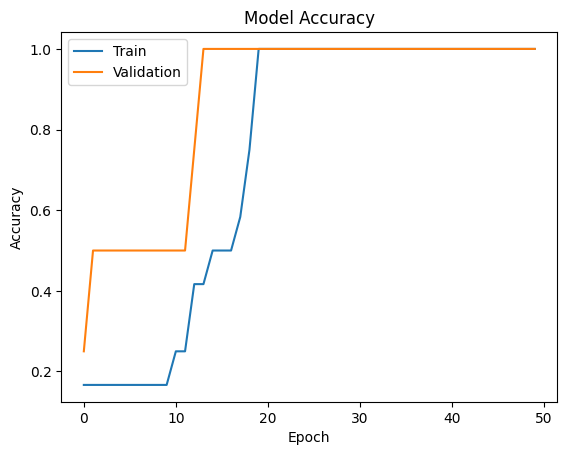

In [10]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()